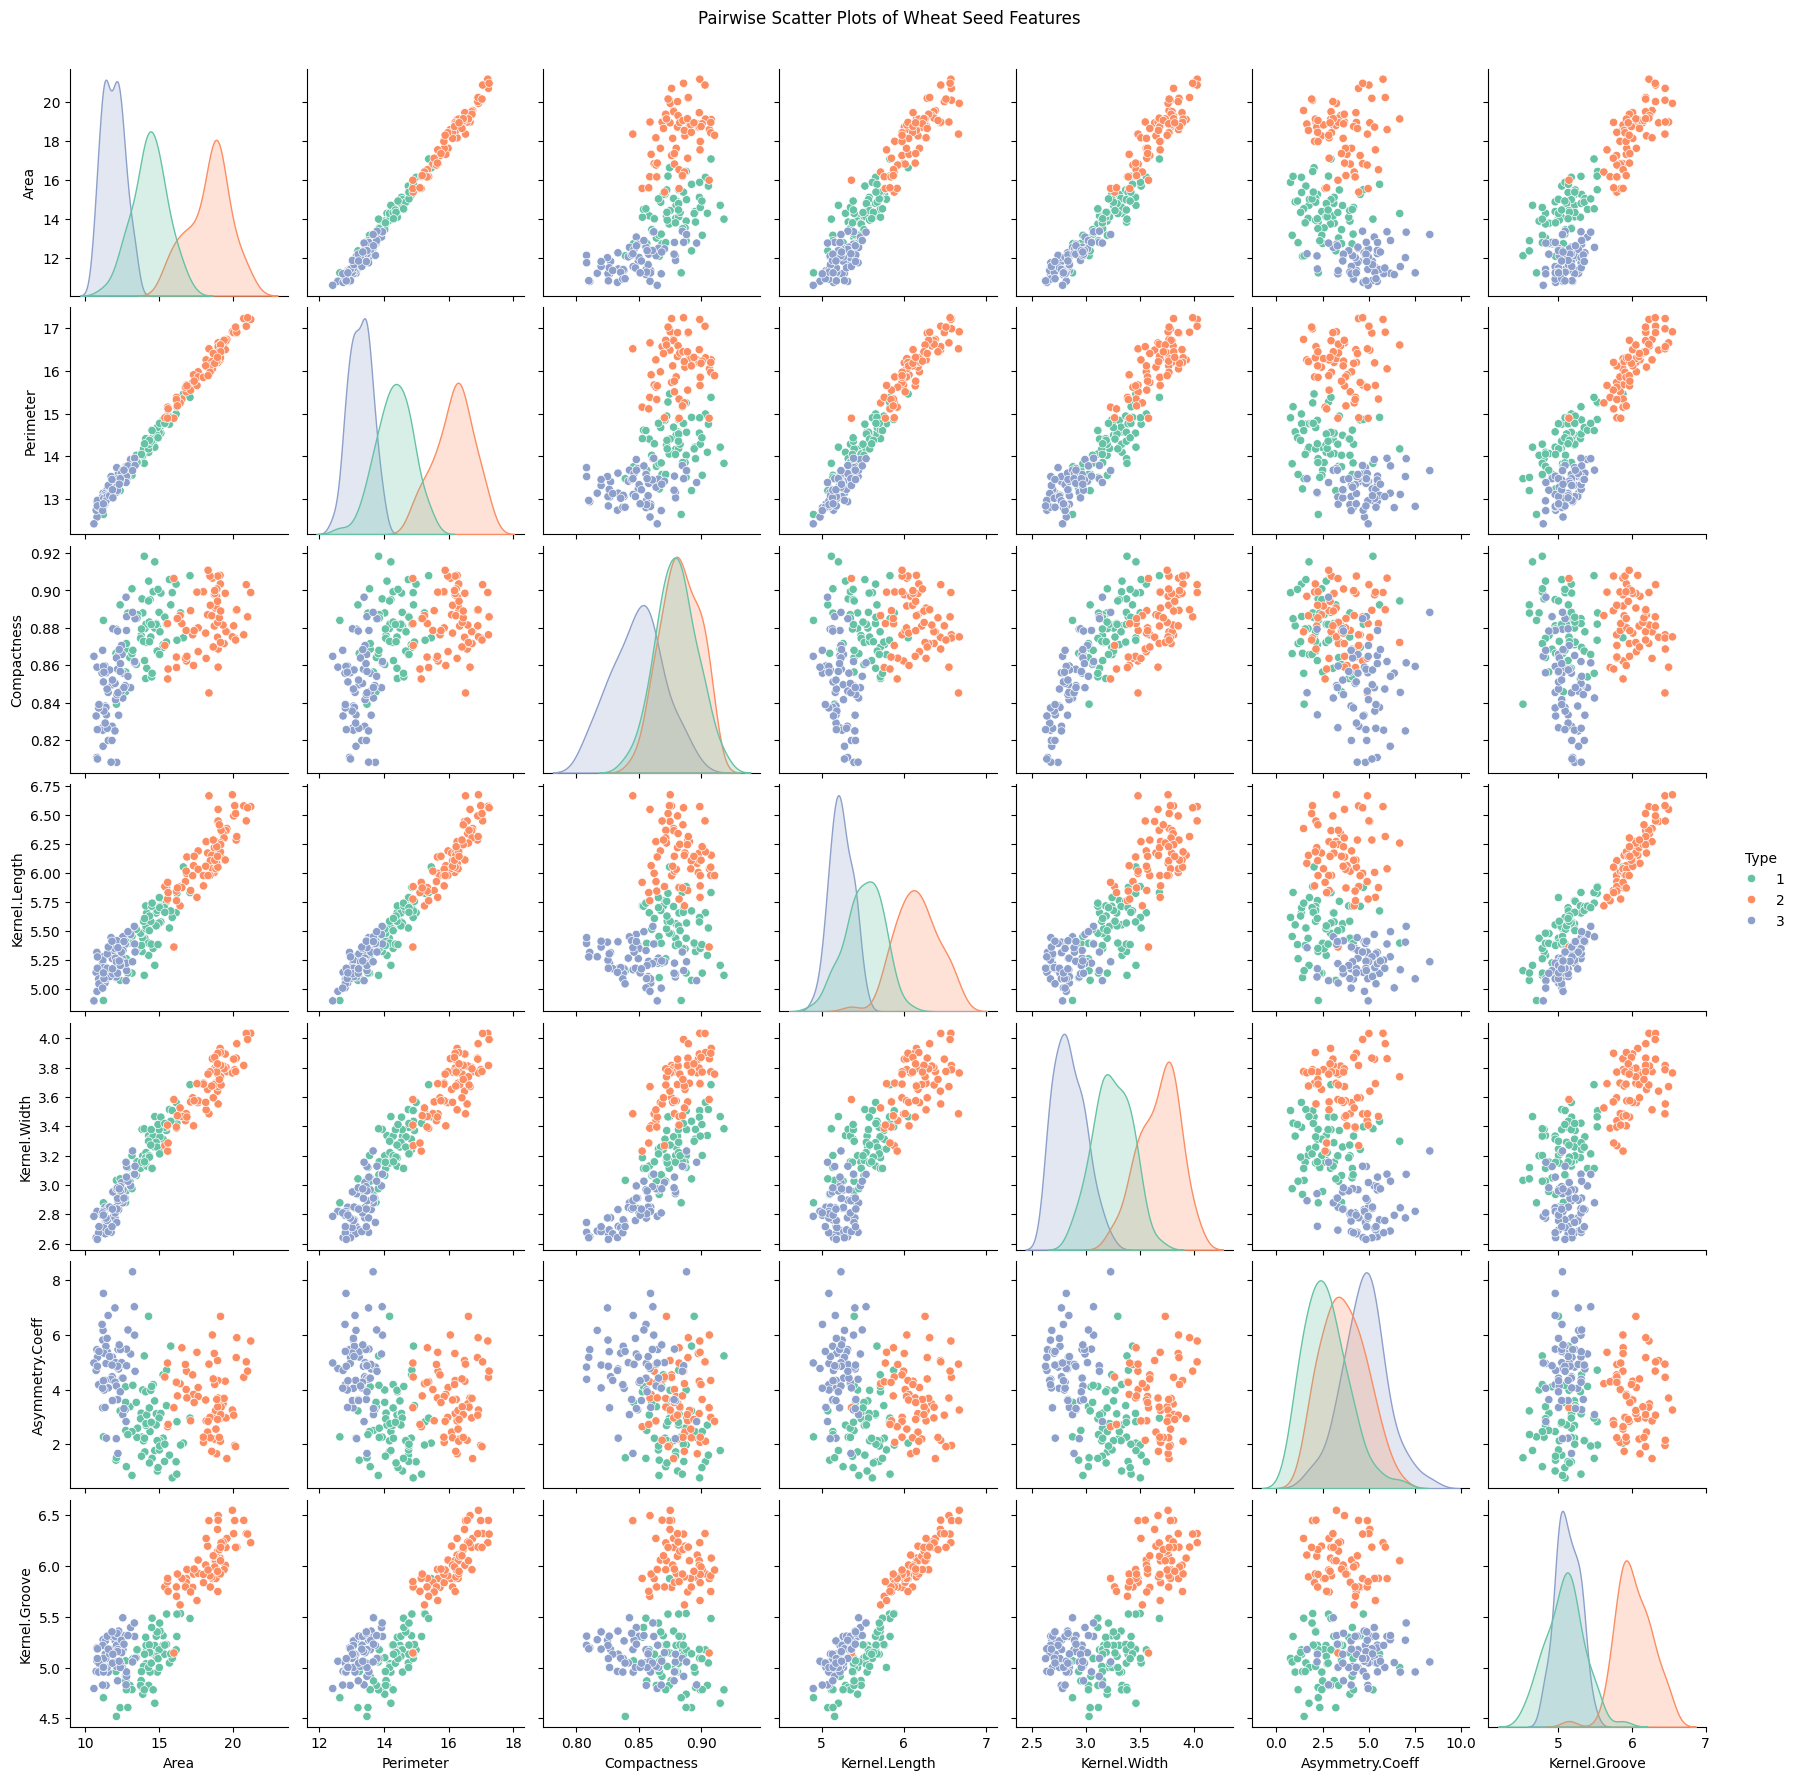

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/seeds.csv')

# Pairwise scatter plots
sns.pairplot(data, hue='Type', palette='Set2')
plt.suptitle('Pairwise Scatter Plots of Wheat Seed Features', y=1.02)
plt.show()

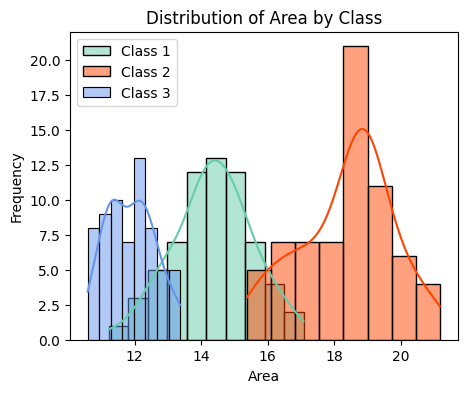

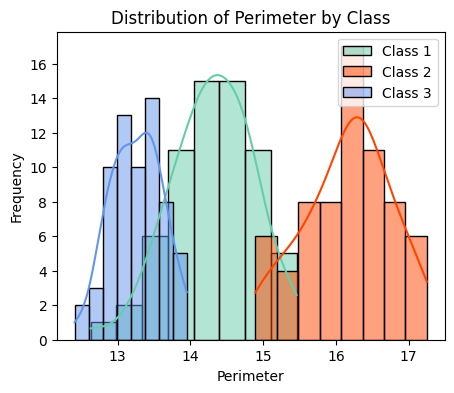

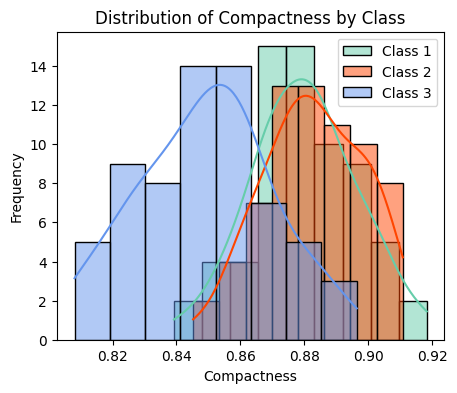

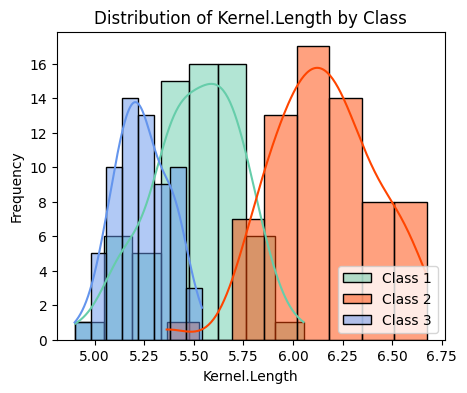

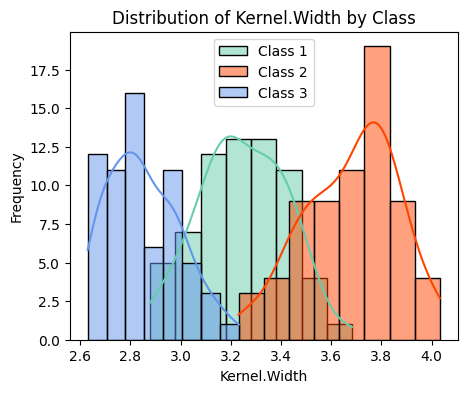

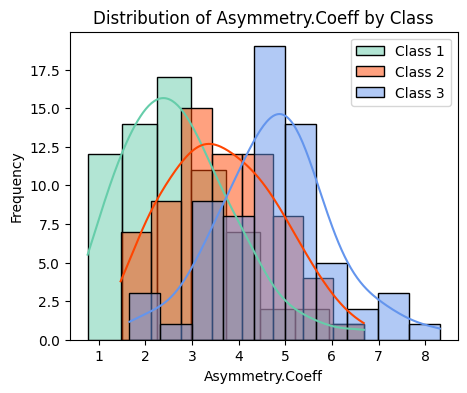

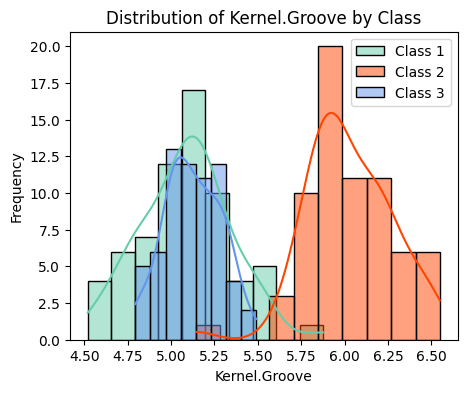

In [22]:
# Separate data by class
class_1 = data[data['Type'] == 1]
class_2 = data[data['Type'] == 2]
class_3 = data[data['Type'] == 3]

# Plot histograms for each feature
for feature in data.columns[:-1]:
    plt.figure(figsize=(5, 4))
    sns.histplot(class_1[feature], color='mediumaquamarine', label='Class 1', kde=True)
    sns.histplot(class_2[feature], color='orangered', label='Class 2', kde=True)
    sns.histplot(class_3[feature], color='cornflowerblue', label='Class 3', kde=True)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [24]:
import numpy as np

# Separate features and target variable
X = data.drop(columns=['Type'])
y = data['Type']

def robust_scaling(data):
    median = np.median(data, axis=0)
    quartile_1 = np.percentile(data, 25, axis=0)
    quartile_3 = np.percentile(data, 75, axis=0)
    iqr = quartile_3 - quartile_1
    scaled_data = (data - median) / iqr
    return scaled_data, median, iqr

# Apply robust_scaling normalization
X_normalized, median, iqr = robust_scaling(X)

# Convert back to DataFrame
X_normalized_df = pd.DataFrame(X_normalized, columns=X.columns)

# Check scaled data
print(X_normalized_df.head())

       Area  Perimeter  Compactness  Kernel.Length  Kernel.Width  \
0  0.161951   0.201285    -0.080808       0.302041      0.109836   
1  0.087805   0.085653     0.259259       0.017687      0.144262   
2 -0.027317  -0.119914     1.063973      -0.340136      0.150820   
3 -0.115122  -0.184154     0.744108      -0.295238      0.219672   
4  0.333659   0.265525     1.010101       0.159184      0.519672   

   Asymmetry.Coeff  Kernel.Groove  
0        -0.632571      -0.009604  
1        -1.172275      -0.326531  
2        -0.418125      -0.483794  
3        -0.615523      -0.507803  
4        -1.021086      -0.063625  


In [58]:
# Split data into training and test sets
def train_test_split(X, y, test_ratio=0.2, random_seed=None):
    m = X.shape[0]
    split_index = int((1 - test_ratio) * m)

    if random_seed is not None:
        np.random.seed(random_seed)

    indices = np.random.permutation(m)
    train_indices, test_indices = indices[:split_index], indices[split_index:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    return X_train, X_test, y_train, y_test

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Logistic Regression
def logistic_regression(X, y, num_iterations, learning_rate):
    m, n = X.shape
    intercept = np.ones((m, 1))
    X = np.concatenate((intercept, X), axis=1)
    theta = np.zeros(n + 1)

    for _ in range(num_iterations):
        z = np.dot(X, theta)
        h = sigmoid(z)
        gradient = np.dot(X.T, (h - y)) / m
        theta -= learning_rate * gradient

    return theta

# One vs All Logistic Regression
def one_vs_all_logistic_regression(X_train, y_train, num_iterations, learning_rate):
    num_classes = len(np.unique(y_train))
    theta_values = []

    for c in range(1, num_classes + 1):
        # Convert labels to binary (0 or 1) for the current class
        y_binary = np.where(y_train == c, 1, 0)

        # Train logistic regression for the current class
        theta = logistic_regression(X_train, y_binary, num_iterations, learning_rate)
        theta_values.append(theta)

    return theta_values

# Predictions
def predict(X, theta):
    m = X.shape[0]
    intercept = np.ones((m, 1))
    X = np.concatenate((intercept, X), axis=1)
    predictions = sigmoid(np.dot(X, theta))
    return predictions

# Predictions for One vs All
def predict_one_vs_all(X, theta_values):
    num_classes = len(theta_values)
    m = X.shape[0]
    predictions = np.zeros((m, num_classes))

    for c in range(num_classes):
        theta = theta_values[c]
        class_probabilities = predict(X, theta)
        predictions[:, c] = class_probabilities

    # Predict the class with the highest probability
    predicted_classes = np.argmax(predictions, axis=1) + 1
    return predicted_classes

# Evaluation Metrics
def accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

def precision(y_true, y_pred, positive_class):
    true_positives = np.sum((y_true == positive_class) & (y_pred == positive_class))
    predicted_positives = np.sum(y_pred == positive_class)
    return true_positives / predicted_positives if predicted_positives != 0 else 0

def recall(y_true, y_pred, positive_class):
    true_positives = np.sum((y_true == positive_class) & (y_pred == positive_class))
    actual_positives = np.sum(y_true == positive_class)
    return true_positives / actual_positives if actual_positives != 0 else 0

def f1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for i in range(num_classes):
        for j in range(num_classes):
            cm[i, j] = np.sum((y_true == i+1) & (y_pred == j+1))
    return cm

# Separate features and target variable
X = X_normalized_df
y = data['Type']

# Convert data to numpy arrays
X_np = X_normalized_df.values
y_np = y.values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_ratio=0.2, random_seed=42)
# Train model
num_iterations = 1000
learning_rate = 0.01
theta_values = one_vs_all_logistic_regression(X_train, y_train, num_iterations, learning_rate)

def evaluate_performance(X, y, theta_values, dataset_name):
    y_pred = predict_one_vs_all(X, theta_values)
    acc = accuracy(y, y_pred)

    precisions = [precision(y, y_pred, c) for c in range(1, 4)]
    recalls = [recall(y, y_pred, c) for c in range(1, 4)]
    f1_scores = [f1_score(precisions[i], recalls[i]) for i in range(3)]
    conf_matrix = confusion_matrix(y, y_pred, num_classes=3)

    precisions_b = np.mean(precisions)
    recalls_b = np.mean(recalls)
    f1_scores_b = np.mean(f1_scores)

    print(f"Evaluation Metrics for {dataset_name} Set:")
    print("Accuracy:", round(acc, 4))
    print("\nPrecision:", [round(p, 4) for p in precisions])
    print("Precision_bar:", round(precisions_b, 4))
    print("\nRecall:", [round(r, 4) for r in recalls])
    print("Recall_bar:", round(recalls_b, 4))
    print("\nF1-score:", [round(f, 4) for f in f1_scores])
    print("F1-score_bar:", round(f1_scores_b, 4))
    print("\nConfusion Matrix:")
    print(conf_matrix)

# Evaluate train set
evaluate_performance(X_train, y_train, theta_values, "Train")

print("\n=====================================")
# Evaluate test set
evaluate_performance(X_test, y_test, theta_values, "Test")

Evaluation Metrics for Train Set:
Accuracy: 0.8805

Precision: [0.9268, 0.8689, 0.8596]
Precision_bar: 0.8851

Recall: [0.7037, 0.9815, 0.9608]
Recall_bar: 0.882

F1-score: [0.8, 0.9217, 0.9074]
F1-score_bar: 0.8764

Confusion Matrix:
[[38  8  8]
 [ 1 53  0]
 [ 2  0 49]]

Evaluation Metrics for Test Set:
Accuracy: 0.925

Precision: [1.0, 1.0, 0.8235]
Precision_bar: 0.9412

Recall: [0.75, 1.0, 1.0]
Recall_bar: 0.9167

F1-score: [0.8571, 1.0, 0.9032]
F1-score_bar: 0.9201

Confusion Matrix:
[[ 9  0  3]
 [ 0 14  0]
 [ 0  0 14]]


Accuracy for k=1: 0.95
Accuracy for k=2: 0.95
Accuracy for k=3: 0.95
Accuracy for k=4: 0.975
Accuracy for k=5: 0.925
Accuracy for k=6: 0.975
Accuracy for k=7: 0.925
Accuracy for k=8: 0.95
Accuracy for k=9: 0.925
Accuracy for k=10: 0.95


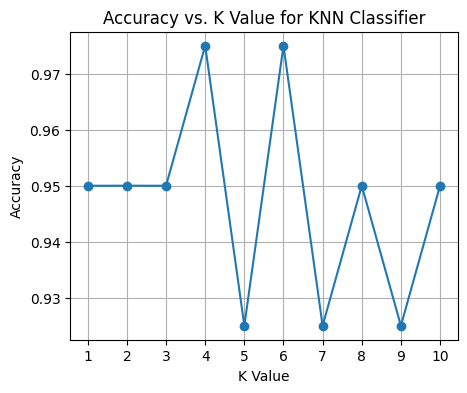

Best K value: 4 with accuracy: 0.975


In [59]:
# calculate Euclidean distance between two points
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

# KNN classifier function
def knn_classifier(X_train, y_train, X_test, k):
    y_pred = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]
        sorted_indices = np.argsort(distances)
        k_nearest_indices = sorted_indices[:k]
        k_nearest_labels = [y_train[i] for i in k_nearest_indices]
        # Choose the most common label among the k nearest neighbors
        pred_label = max(set(k_nearest_labels), key=k_nearest_labels.count)
        y_pred.append(pred_label)
    return y_pred

# accuracy function
def calculate_accuracy(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    total = len(y_true)
    return correct / total

# Test different values of K
k_values = list(range(1, 11))
accuracies = []

for k in k_values:
    y_pred = knn_classifier(X_train, y_train, X_test, k)
    accuracy = calculate_accuracy(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"Accuracy for k={k}: {accuracy}")

# Plot accuracy for different values of K
plt.figure(figsize=(5, 4))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('Accuracy vs. K Value for KNN Classifier')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# reporting best K value
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)
print(f"Best K value: {best_k} with accuracy: {best_accuracy}")

# **Without Randomseed**

In [25]:
# Split data into training and test sets
def train_test_split(X, y, test_ratio=0.2):
    m = X.shape[0]
    split_index = int((1 - test_ratio) * m)
    indices = np.random.permutation(m)
    train_indices, test_indices = indices[:split_index], indices[split_index:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    return X_train, X_test, y_train, y_test

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Logistic Regression
def logistic_regression(X, y, num_iterations, learning_rate):
    m, n = X.shape
    intercept = np.ones((m, 1))
    X = np.concatenate((intercept, X), axis=1)
    theta = np.zeros(n + 1)

    for _ in range(num_iterations):
        z = np.dot(X, theta)
        h = sigmoid(z)
        gradient = np.dot(X.T, (h - y)) / m
        theta -= learning_rate * gradient

    return theta

# One vs All Logistic Regression
def one_vs_all_logistic_regression(X_train, y_train, num_iterations, learning_rate):
    num_classes = len(np.unique(y_train))
    theta_values = []

    for c in range(1, num_classes + 1):
        # Convert labels to binary (0 or 1) for the current class
        y_binary = np.where(y_train == c, 1, 0)

        # Train logistic regression for the current class
        theta = logistic_regression(X_train, y_binary, num_iterations, learning_rate)
        theta_values.append(theta)

    return theta_values

# Predictions
def predict(X, theta):
    m = X.shape[0]
    intercept = np.ones((m, 1))
    X = np.concatenate((intercept, X), axis=1)
    predictions = sigmoid(np.dot(X, theta))
    return predictions

# Predictions for One vs All
def predict_one_vs_all(X, theta_values):
    num_classes = len(theta_values)
    m = X.shape[0]
    predictions = np.zeros((m, num_classes))

    for c in range(num_classes):
        theta = theta_values[c]
        class_probabilities = predict(X, theta)
        predictions[:, c] = class_probabilities

    # Predict the class with the highest probability
    predicted_classes = np.argmax(predictions, axis=1) + 1
    return predicted_classes

# Evaluation Metrics
def accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

def precision(y_true, y_pred, positive_class):
    true_positives = np.sum((y_true == positive_class) & (y_pred == positive_class))
    predicted_positives = np.sum(y_pred == positive_class)
    return true_positives / predicted_positives if predicted_positives != 0 else 0

def recall(y_true, y_pred, positive_class):
    true_positives = np.sum((y_true == positive_class) & (y_pred == positive_class))
    actual_positives = np.sum(y_true == positive_class)
    return true_positives / actual_positives if actual_positives != 0 else 0

def f1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for i in range(num_classes):
        for j in range(num_classes):
            cm[i, j] = np.sum((y_true == i+1) & (y_pred == j+1))
    return cm

# Separate features and target variable
X = X_normalized_df
y = data['Type']

# Convert data to numpy arrays
X_np = X_normalized_df.values
y_np = y.values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_ratio=0.2)

# Train model
num_iterations = 1000
learning_rate = 0.01
theta_values = one_vs_all_logistic_regression(X_train, y_train, num_iterations, learning_rate)

def evaluate_performance(X, y, theta_values, dataset_name):
    y_pred = predict_one_vs_all(X, theta_values)
    acc = accuracy(y, y_pred)

    precisions = [precision(y, y_pred, c) for c in range(1, 4)]
    recalls = [recall(y, y_pred, c) for c in range(1, 4)]
    f1_scores = [f1_score(precisions[i], recalls[i]) for i in range(3)]
    conf_matrix = confusion_matrix(y, y_pred, num_classes=3)

    precisions_b = np.mean(precisions)
    recalls_b = np.mean(recalls)
    f1_scores_b = np.mean(f1_scores)

    print(f"Evaluation Metrics for {dataset_name} Set:")
    print("Accuracy:", round(acc, 4))
    print("\nPrecision:", [round(p, 4) for p in precisions])
    print("Precision_bar:", round(precisions_b, 4))
    print("\nRecall:", [round(r, 4) for r in recalls])
    print("Recall_bar:", round(recalls_b, 4))
    print("\nF1-score:", [round(f, 4) for f in f1_scores])
    print("F1-score_bar:", round(f1_scores_b, 4))
    print("\nConfusion Matrix:")
    print(conf_matrix)

# Evaluate train set
evaluate_performance(X_train, y_train, theta_values, "Train")

print("\n=====================================")
# Evaluate test set
evaluate_performance(X_test, y_test, theta_values, "Test")

Evaluation Metrics for Train Set:
Accuracy: 0.8805

Precision: [0.9474, 0.8871, 0.8305]
Precision_bar: 0.8883

Recall: [0.6792, 1.0, 0.9608]
Recall_bar: 0.88

F1-score: [0.7912, 0.9402, 0.8909]
F1-score_bar: 0.8741

Confusion Matrix:
[[36  7 10]
 [ 0 55  0]
 [ 2  0 49]]

Evaluation Metrics for Test Set:
Accuracy: 0.925

Precision: [0.9167, 0.9231, 0.9333]
Precision_bar: 0.9244

Recall: [0.8462, 0.9231, 1.0]
Recall_bar: 0.9231

F1-score: [0.88, 0.9231, 0.9655]
F1-score_bar: 0.9229

Confusion Matrix:
[[11  1  1]
 [ 1 12  0]
 [ 0  0 14]]


Accuracy for k=1: 0.975
Accuracy for k=2: 1.0
Accuracy for k=3: 0.975
Accuracy for k=4: 0.975
Accuracy for k=5: 0.95
Accuracy for k=6: 0.95
Accuracy for k=7: 0.95
Accuracy for k=8: 0.95
Accuracy for k=9: 0.95
Accuracy for k=10: 0.95


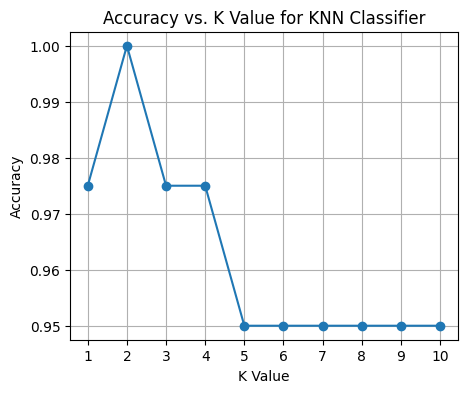

Best K value: 2 with accuracy: 1.0


In [ ]:
# calculate Euclidean distance between two points
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

# KNN classifier function
def knn_classifier(X_train, y_train, X_test, k):
    y_pred = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]
        sorted_indices = np.argsort(distances)
        k_nearest_indices = sorted_indices[:k]
        k_nearest_labels = [y_train[i] for i in k_nearest_indices]
        # Choose the most common label among the k nearest neighbors
        pred_label = max(set(k_nearest_labels), key=k_nearest_labels.count)
        y_pred.append(pred_label)
    return y_pred

# accuracy function
def calculate_accuracy(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    total = len(y_true)
    return correct / total

# Test different values of K
k_values = list(range(1, 11))
accuracies = []

for k in k_values:
    y_pred = knn_classifier(X_train, y_train, X_test, k)
    accuracy = calculate_accuracy(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"Accuracy for k={k}: {accuracy}")

# Plot accuracy for different values of K
plt.figure(figsize=(5, 4))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('Accuracy vs. K Value for KNN Classifier')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# reporting best K value
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)
print(f"Best K value: {best_k} with accuracy: {best_accuracy}")